# Lab 1: Impact of Padding and Strides in Convolutional Layers

# Goal: Understand how padding='valid' vs 'same' and different stride values

In [8]:
import tensorflow as tf

from tensorflow import keras

from tensorflow.keras import layers

import numpy as np

import matplotlib.pyplot as plt

import time

%matplotlib inline

# 1. Load and prepare MNIST (simple grayscale dataset)

In [9]:
# ────────────────────────────────────────────────

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()



x_train = x_train.astype("float32") / 255.0

x_test  = x_test.astype("float32")  / 255.0



x_train = np.expand_dims(x_train, -1)   # (N,28,28,1)

x_test  = np.expand_dims(x_test, -1)



y_train = keras.utils.to_categorical(y_train, 10)

y_test  = keras.utils.to_categorical(y_test, 10)



print("Data ready. Shape:", x_train.shape)

Data ready. Shape: (60000, 28, 28, 1)


# 2. Function to build a simple CNN with configurable conv settings

In [10]:
def build_cnn(padding='valid', strides=(1,1), kernel_size=3):

    model = keras.Sequential([

        layers.Input(shape=(28,28,1)),



        layers.Conv2D(32, kernel_size,

                      padding=padding,

                      strides=strides,

                      activation='relu'),

        layers.MaxPooling2D(pool_size=(2,2)),



        layers.Conv2D(64, kernel_size,

                      padding=padding,

                      strides=strides,

                      activation='relu'),

        layers.MaxPooling2D(pool_size=(2,2)),



        layers.Flatten(),

        layers.Dense(128, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')

    ])



    model.compile(optimizer='adam',

                  loss='categorical_crossentropy',

                  metrics=['accuracy'])



    return model

# 3. Experiment configurations


Running experiment: Baseline (same padding, stride 1)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8280 - loss: 0.5590 - val_accuracy: 0.9850 - val_loss: 0.0537
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9770 - loss: 0.0736 - val_accuracy: 0.9873 - val_loss: 0.0441
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9837 - loss: 0.0527 - val_accuracy: 0.9875 - val_loss: 0.0405
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0389 - val_accuracy: 0.9902 - val_loss: 0.0361
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9909 - loss: 0.0299 - val_accuracy: 0.9872 - val_loss: 0.0396
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9919 - loss: 0.0273 - val_accuracy: 0.9893 - val_loss: 0.0371
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9915 - val_loss: 0.0327
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9946 - loss: 0.0194 - val_accuracy: 0.9905 - 

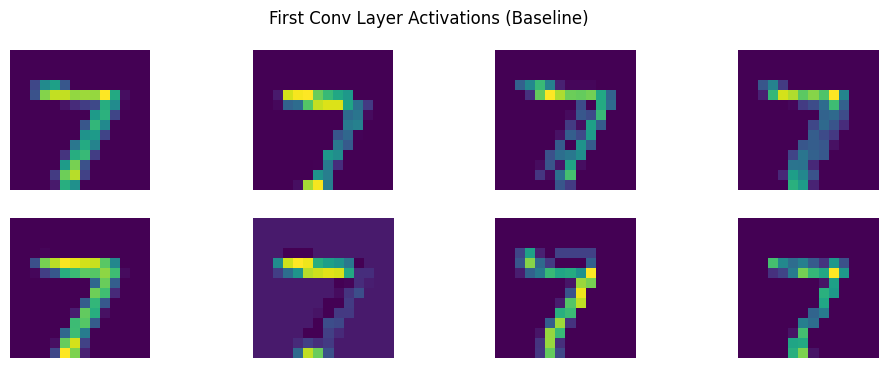


Running experiment: No padding (valid), stride 1


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 10, 10, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 2, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6074 - loss: 1.2087 - val_accuracy: 0.9215 - val_loss: 0.2573
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.3148 - val_accuracy: 0.9493 - val_loss: 0.1722
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9304 - loss: 0.2267 - val_accuracy: 0.9587 - val_loss: 0.1361
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9436 - loss: 0.1821 - val_accuracy: 0.9645 - val_loss: 0.1207
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9515 - loss: 0.1582 - val_accuracy: 0.9678 - val_loss: 0.1055
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9561 - loss: 0.1388 - val_accuracy: 0.9695 - val_loss: 0.1000
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9597 - loss: 0.1253 - val_accuracy: 0.9692 - val_loss: 0.1049
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9646 - loss: 0.1142 - val_accuracy: 0.9688 - v

In [12]:
experiments = [

    {"name": "Baseline (same padding, stride 1)",     "padding": "same",  "strides": (1,1)},

    {"name": "No padding (valid), stride 1",          "padding": "valid", "strides": (1,1)},

    {"name": "Same padding, stride 2",                "padding": "same",  "strides": (2,2)},

    {"name": "Valid padding, stride 2",               "padding": "valid", "strides": (2,2)},

    {"name": "Same padding, stride 3",                "padding": "same",  "strides": (3,3)},

]



results = []



for exp in experiments:

    print(f"\n{'='*60}")
    print(f"Running experiment: {exp['name']}")

    model = build_cnn(padding=exp["padding"], strides=exp["strides"])
    model.summary()

    start_time = time.time()

    history = model.fit(x_train, y_train,
                        batch_size=128,
                        epochs=8,
                        validation_split=0.1,
                        verbose=1)

    train_time = time.time() - start_time

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "name": exp["name"],
        "padding": exp["padding"],
        "strides": exp["strides"],
        "train_time_sec": round(train_time, 1),
        "test_accuracy": round(test_acc, 4),
        "final_val_acc": round(history.history['val_accuracy'][-1], 4),
        "num_params": model.count_params()
    })

    # Visualization for baseline only
    if len(results) == 1:

        intermediate_model = keras.Model(
            inputs=model.inputs,
            outputs=model.layers[1].output
        )

        act = intermediate_model.predict(x_test[:1])

        plt.figure(figsize=(12,4))

        for i in range(8):
            plt.subplot(2,4,i+1)
            plt.imshow(act[0,:,:,i], cmap='viridis')
            plt.axis('off')

        plt.suptitle("First Conv Layer Activations (Baseline)")
        plt.show()

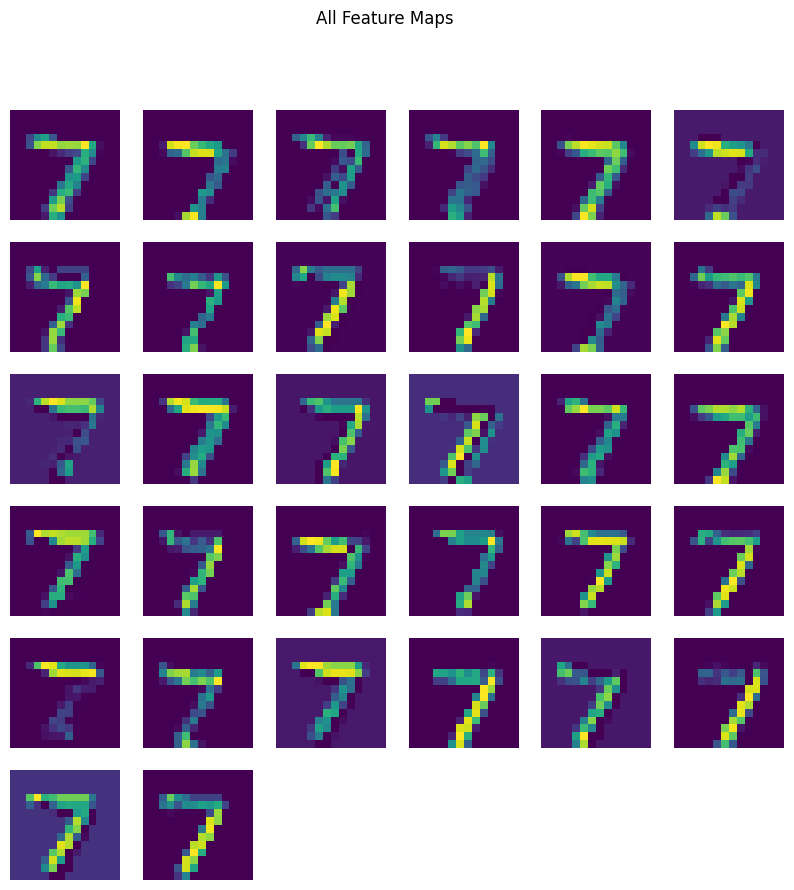

In [13]:
num_filters = act.shape[-1]

plt.figure(figsize=(10,10))

for i in range(num_filters):
    plt.subplot(6,6,i+1)
    plt.imshow(act[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("All Feature Maps")
plt.show()

In [14]:
import pandas as pd

df = pd.DataFrame(results)
print("\nExperiment Summary")
display(df)


Experiment Summary


,name,padding,strides,train_time_sec,test_accuracy,final_val_acc,num_params
0,"Baseline (same padding, stride 1)",same,"(1, 1)",22.9,0.9922,0.9905,421642
1,"No padding (valid), stride 1",valid,"(1, 1)",20.0,0.9920,0.9913,225034
2,"Same padding, stride 2",same,"(2, 2)",17.8,0.9852,0.9867,53002
3,"Valid padding, stride 2",valid,"(2, 2)",17.2,0.9727,0.9780,28426
4,"Same padding, stride 3",same,"(3, 3)",16.8,0.9641,0.9688,28426


# 4. Summary Table

In [15]:
print("\n" + "="*80)

print("EXPERIMENT SUMMARY")

print("-"*80)

print(f"{'Config':<35} {'Padding':<10} {'Stride':<8} {'Params':<12} {'Train Time':<12} {'Test Acc':<10}")

print("-"*80)

for r in results:

    print(f"{r['name']:<35} {r['padding']:<10} {str(r['strides']):<8} {r['num_params']:<12,} {r['train_time_sec']:<12} {r['test_accuracy']:<10.4f}")

print("="*80)



print("\nKey observations to discuss:")

print("• 'same' padding usually gives slightly higher accuracy (preserves edges)")

print("• Higher strides → much fewer parameters and faster training, but accuracy drops")

print("• Trade-off becomes more obvious on harder datasets (try CIFAR-10 next)")


EXPERIMENT SUMMARY
--------------------------------------------------------------------------------
Config                              Padding    Stride   Params       Train Time   Test Acc  
--------------------------------------------------------------------------------
Baseline (same padding, stride 1)   same       (1, 1)   421,642      22.9         0.9922    
No padding (valid), stride 1        valid      (1, 1)   225,034      20.0         0.9920    
Same padding, stride 2              same       (2, 2)   53,002       17.8         0.9852    
Valid padding, stride 2             valid      (2, 2)   28,426       17.2         0.9727    
Same padding, stride 3              same       (3, 3)   28,426       16.8         0.9641    

Key observations to discuss:
• 'same' padding usually gives slightly higher accuracy (preserves edges)
• Higher strides → much fewer parameters and faster training, but accuracy drops
• Trade-off becomes more obvious on harder datasets (try CIFAR-10 next)
